### 1. Load and Prepare the Data
We will use the built-in California Housing CSV files available in Colab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

# Load datasets
train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')

display(train_df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


### 2. Linear Regression
**Goal**: Predict the continuous value `median_house_value` using `total_rooms`.

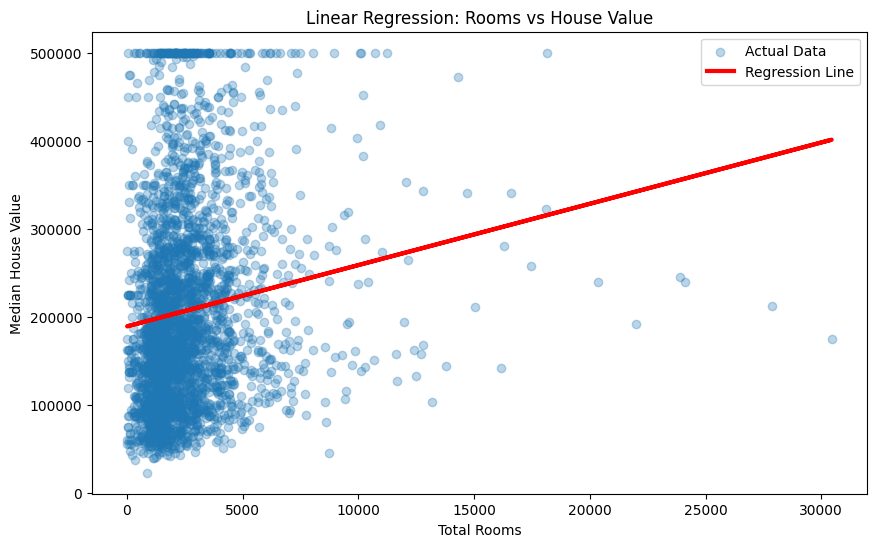

In [2]:
# Prepare data (using total_rooms to predict value)
X_train_lin = train_df[['total_rooms']]
y_train_lin = train_df['median_house_value']
X_test_lin = test_df[['total_rooms']]
y_test_lin = test_df['median_house_value']

# Initialize and train model
lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train_lin)

# Predict
y_pred_lin = lin_model.predict(X_test_lin)

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_test_lin, y_test_lin, alpha=0.3, label='Actual Data')
plt.plot(X_test_lin, y_pred_lin, color='red', linewidth=3, label='Regression Line')
plt.title('Linear Regression: Rooms vs House Value')
plt.xlabel('Total Rooms')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

### 3. Logistic Regression
**Goal**: Predict a category. We will create a binary label: `1` if the house value is above the median, `0` otherwise.

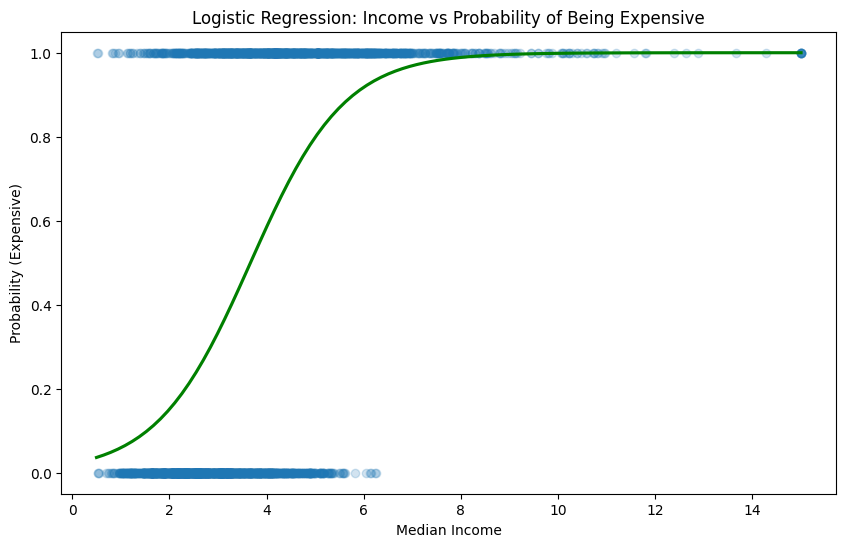

In [3]:
# Create binary target
median_val = train_df['median_house_value'].median()
train_df['is_expensive'] = (train_df['median_house_value'] > median_val).astype(int)
test_df['is_expensive'] = (test_df['median_house_value'] > median_val).astype(int)

# Use median_income as a feature (it has a high correlation with price)
X_train_log = train_df[['median_income']]
y_train_log = train_df['is_expensive']
X_test_log = test_df[['median_income']]
y_test_log = test_df['is_expensive']

# Train model
log_model = LogisticRegression()
log_model.fit(X_train_log, y_train_log)

# Visualization: Sigmoid Curve
plt.figure(figsize=(10, 6))
sns.regplot(x='median_income', y='is_expensive', data=test_df, logistic=True, ci=None,
            scatter_kws={'alpha':0.2}, line_kws={'color':'green'})
plt.title('Logistic Regression: Income vs Probability of Being Expensive')
plt.xlabel('Median Income')
plt.ylabel('Probability (Expensive)')
plt.show()